# 👥 Análisis de clientes

Este notebook explora patrones de comportamiento, satisfacción y desempeño logístico dentro del marketplace de e-commerce.

El objetivo es identificar insights accionables relacionados con:
- distribución geográfica de clientes,
- experiencia del usuario,
- tiempos de entrega,
- categorías estratégicas,
- y variables que impactan la satisfacción del cliente.

# 📂 Carga del dataset maestro

In [66]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use('ggplot')
sns.set(font_scale=1.1)

# Cargar dataset maestro
df = pd.read_csv('../data/master_dataset.csv')

# Vista previa
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,payment_type,payment_installments,payment_value,review_score,product_category_name_english,customer_state,total_revenue,purchase_month,delivery_time_days,delivery_delay
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,credit_card,1.0,18.12,4.0,housewares,SP,38.71,2017-10,8.0,-8.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,voucher,1.0,2.00,4.0,housewares,SP,38.71,2017-10,8.0,-8.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,voucher,1.0,18.59,4.0,housewares,SP,38.71,2017-10,8.0,-8.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,boleto,1.0,141.46,4.0,perfumery,BA,141.46,2018-07,13.0,-6.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,credit_card,3.0,179.12,5.0,auto,GO,179.12,2018-08,9.0,-18.0


In [67]:
# Conversión de fechas

df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

df['order_delivered_customer_date'] = pd.to_datetime(
    df['order_delivered_customer_date']
)

df['order_estimated_delivery_date'] = pd.to_datetime(
    df['order_estimated_delivery_date']
)

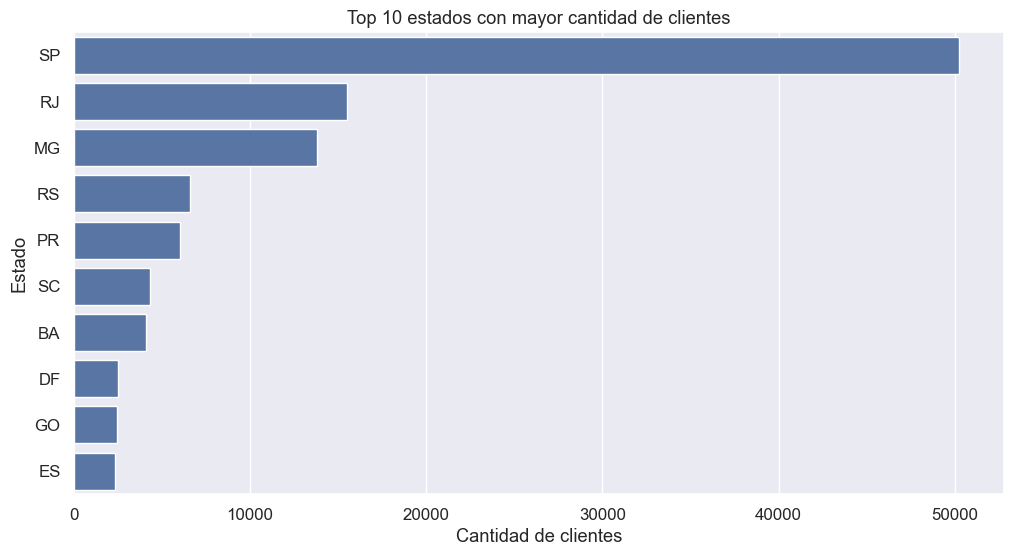

In [68]:
top_states = (
    df['customer_state']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title('Top 10 estados con mayor cantidad de clientes')
plt.xlabel('Cantidad de clientes')
plt.ylabel('Estado')

plt.show()

## 📌 Insight

El estado de São Paulo (SP) concentra significativamente la mayor cantidad de clientes, lo cual sugiere una fuerte dependencia comercial de esta región.

También se observa una presencia importante en Río de Janeiro (RJ) y Minas Gerais (MG), consolidando el sudeste brasileño como el principal mercado del e-commerce.

### Implicancia de negocio
La empresa podría priorizar estrategias logísticas y campañas de marketing en estas regiones para maximizar impacto comercial y eficiencia operativa.


---

# ⭐ Distribución de satisfacción del cliente

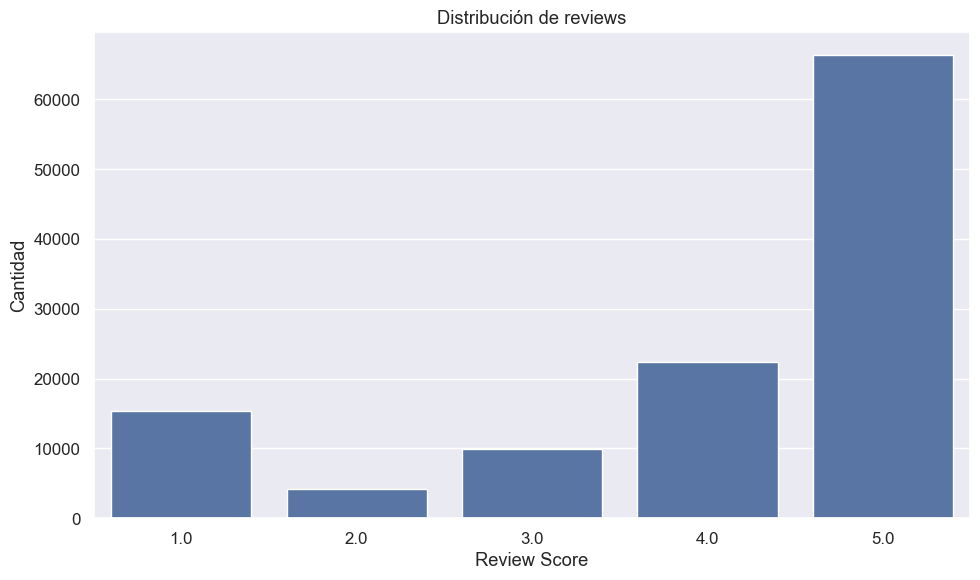

In [69]:
plt.figure(figsize=(10,6))

sns.countplot(
    x=df['review_score']
)

plt.title('Distribución de reviews')
plt.xlabel('Review Score')
plt.ylabel('Cantidad')

plt.tight_layout() 

plt.show()

## 📌 Insight

La mayoría de las evaluaciones corresponden a puntuaciones máximas (5 estrellas), indicando un nivel general de satisfacción elevado.

Sin embargo, existe una proporción relevante de reviews negativas que podrían estar asociadas a problemas logísticos o experiencia de compra.

### Implicancia de negocio
Mantener altos estándares operativos resulta fundamental para preservar la satisfacción del cliente y la reputación de la plataforma.

---

# 🚛 Performance logística

In [70]:
delivery_avg = df['delivery_time_days'].mean()

print(f'Tiempo promedio de entrega: {delivery_avg:.2f} días')

Tiempo promedio de entrega: 12.02 días


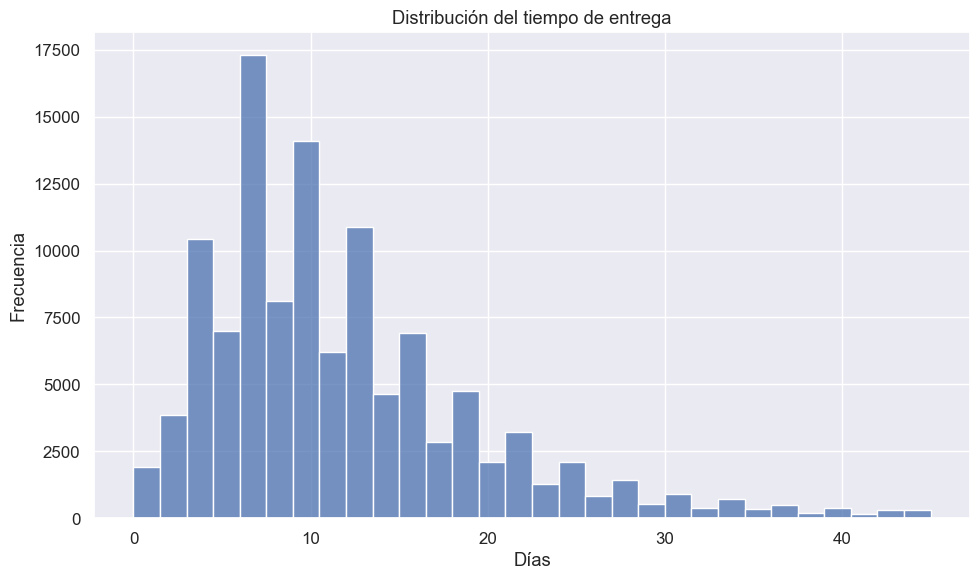

In [71]:
# Filtrado de outliers extremos utilizando percentil 99
limit = df['delivery_time_days'].quantile(0.99)

filtered_delivery = df[
    df['delivery_time_days'] <= limit
]

plt.figure(figsize=(10,6))

sns.histplot(
    filtered_delivery['delivery_time_days'],
    bins=30
)

plt.title('Distribución del tiempo de entrega')
plt.xlabel('Días')
plt.ylabel('Frecuencia')

plt.tight_layout()

plt.show()

## 📌 Insight

La distribución de los tiempos de entrega presenta una fuerte concentración en rangos bajos, con la mayoría de las órdenes entregadas en menos de 20 días.

Para mejorar la interpretación visual, se excluyó el 1% de los casos más extremos mediante un filtrado por percentil 99, reduciendo el impacto de outliers logísticos atípicos.

Aun así, se observa una asimetría positiva moderada, indicando que existen entregas significativamente más lentas que el comportamiento promedio.

### Implicancia de negocio

La consistencia en tiempos de entrega representa un factor clave para la experiencia del cliente. Reducir casos excepcionales de demora podría contribuir directamente a mejorar percepción de servicio, satisfacción y fidelización.


---

# 🛒 Productos y categorías más relevantes

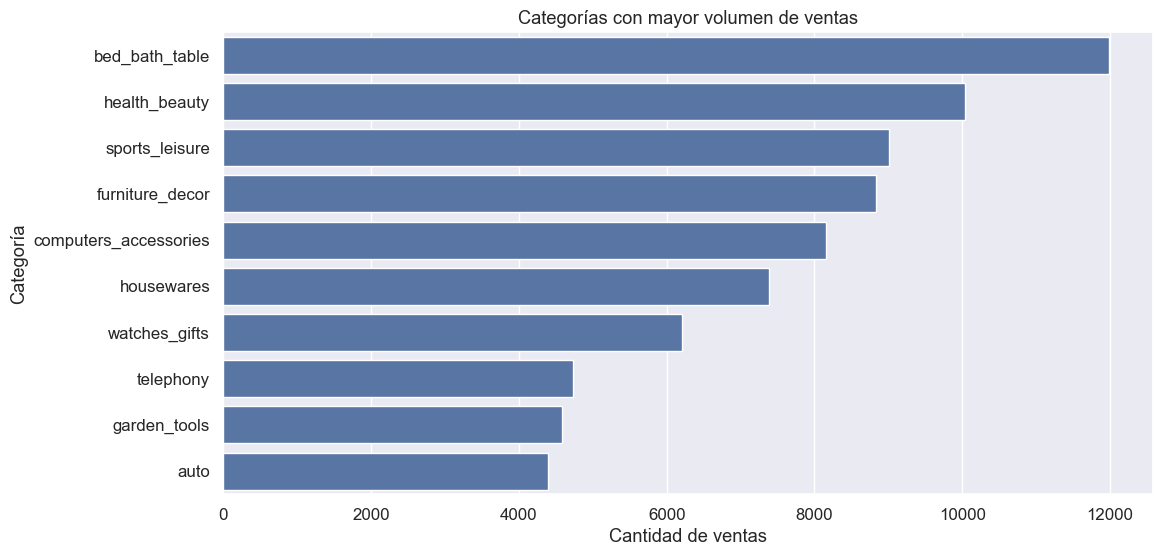

In [72]:
top_products = (
    df.groupby('product_category_name_english')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title('Categorías con mayor volumen de ventas')
plt.xlabel('Cantidad de ventas')
plt.ylabel('Categoría')

plt.show()

## 📌 Insight

Las categorías relacionadas con hogar, decoración y bienestar lideran el volumen de ventas del marketplace.

Esto sugiere patrones de consumo orientados al lifestyle y productos de uso cotidiano.

### Implicancia de negocio
Las categorías líderes representan oportunidades estratégicas para acciones promocionales, fidelización y optimización de inventario.

---



# 📌 Relación entre variables

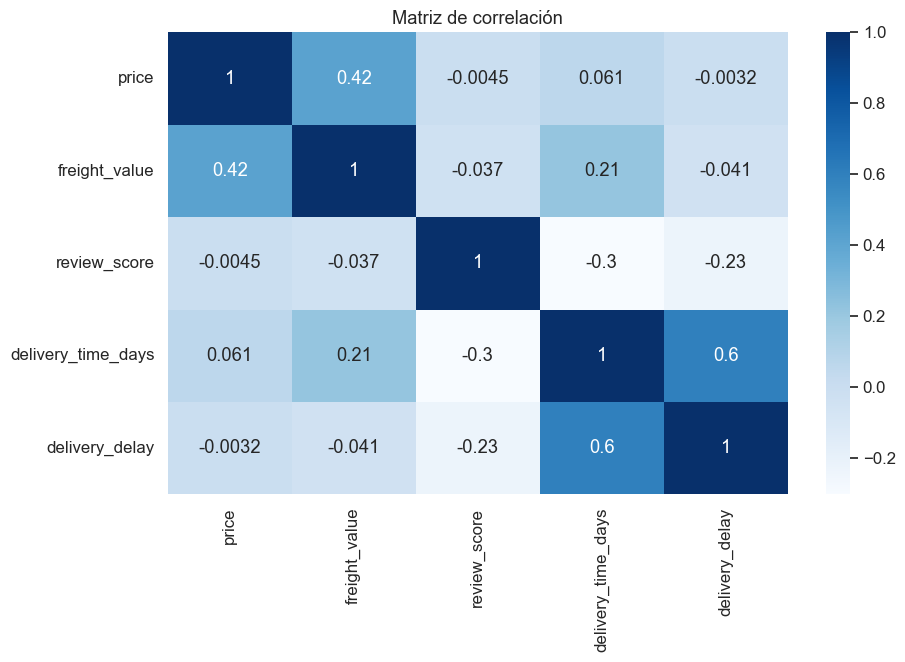

In [73]:
correlation = df[
    [
        'price',
        'freight_value',
        'review_score',
        'delivery_time_days',
        'delivery_delay'
    ]
].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='Blues'
)

plt.title('Matriz de correlación')

plt.show()

## 📌 Insight

Se observa una correlación negativa entre tiempo de entrega y review score, lo que indica que entregas más lentas tienden a relacionarse con menores niveles de satisfacción.

Asimismo, existe una correlación moderada entre delivery time y delivery delay, reflejando consistencia entre tiempos logísticos y retrasos reportados.

### Implicancia de negocio
La logística representa un factor crítico en la experiencia del cliente y puede impactar directamente en la percepción general del servicio.


---

# ⚙️ Metodología

Para este análisis se utilizaron herramientas de análisis exploratorio de datos (EDA) mediante Python y librerías como:

- Pandas
- NumPy
- Matplotlib
- Seaborn

El dataset fue previamente consolidado y transformado para facilitar el análisis de comportamiento de clientes, logística y ventas.


--- 

# 📋 Executive Summary

## Principales hallazgos del análisis

### 1. Concentración geográfica
El estado de São Paulo representa el principal mercado del e-commerce, concentrando una porción significativa de clientes y actividad comercial.

### 2. Alta satisfacción general
La mayoría de los clientes otorgó puntuaciones máximas, reflejando una experiencia positiva en términos generales.

### 3. Impacto logístico en la experiencia
Los tiempos de entrega presentan una relación negativa con la satisfacción del cliente, destacando la importancia de la eficiencia logística.

### 4. Categorías estratégicas
Las categorías relacionadas con hogar, decoración y bienestar concentran gran parte del volumen de ventas y revenue.

---

## Recomendaciones

- Optimizar tiempos de entrega en regiones estratégicas.
- Priorizar categorías de alto rendimiento comercial.
- Monitorear casos extremos de demora logística.
- Continuar fortaleciendo la experiencia del cliente para mantener altos niveles de satisfacción.